In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# 데이터 불러오기
df = pd.read_csv('../data_file/Steel_industry_data.csv')
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [3]:
# date열(문자열) DateTime 객체로 변환 및 인덱스 설정
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date')
df = df.set_index('date')
df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
date,,,,,,,,,,
2018-01-01 00:00:00,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load


In [4]:
# 정상/이상 라벨링
df['label'] = 0
# df.loc[df['Load_Type'] == 'Light_Load', 'label'] = 0
df.loc[(df['Load_Type'] == 'Medium_Load') | (df['Load_Type'] == 'Maximum_Load'), 'label'] = 1

In [5]:
# 데이터가 커서 데이터를 월별로 쪼갠 후 확인
df1 = df.loc[:'2018-01-31']
df2 = df.loc['2018-02-01':'2018-02-28']
df3 = df.loc['2018-03-01':'2018-03-31']
df4 = df.loc['2018-04-01':'2018-04-30']
df5 = df.loc['2018-05-01':'2018-05-31']
df6 = df.loc['2018-06-01':'2018-06-30']
df7 = df.loc['2018-07-01':'2018-07-31']
df8 = df.loc['2018-08-01':'2018-08-31']
df9 = df.loc['2018-09-01':'2018-09-30']
df10 = df.loc['2018-10-01':'2018-10-31']
df11 = df.loc['2018-11-01':'2018-11-30']
df12 = df.loc['2018-12-01':]

In [6]:
# 이상/정상 그래프 출력
def plot_normal_abnormal(df, col_name):
  normal_area = df['label'] == 0
  abnormal_area = df['label'] == 1

  plt.figure(figsize=(20, 10))
  plt.scatter(df.index, df[col_name], label=col_name, s=2)
  plt.fill_between(
    df.index,
    df[col_name].min(),
    df[col_name].max(),
    where=normal_area,
    color='green',
    alpha=0.2,
    step=None,
    label='normal'
    )
  plt.fill_between(
    df.index,
    df[col_name].min(),
    df[col_name].max(),
    where=abnormal_area,
    color='red',
    alpha=0.2,
    step=None,
    label='abnormal'
    )
  plt.legend(loc='upper right')
  plt.title(col_name)
  plt.show()

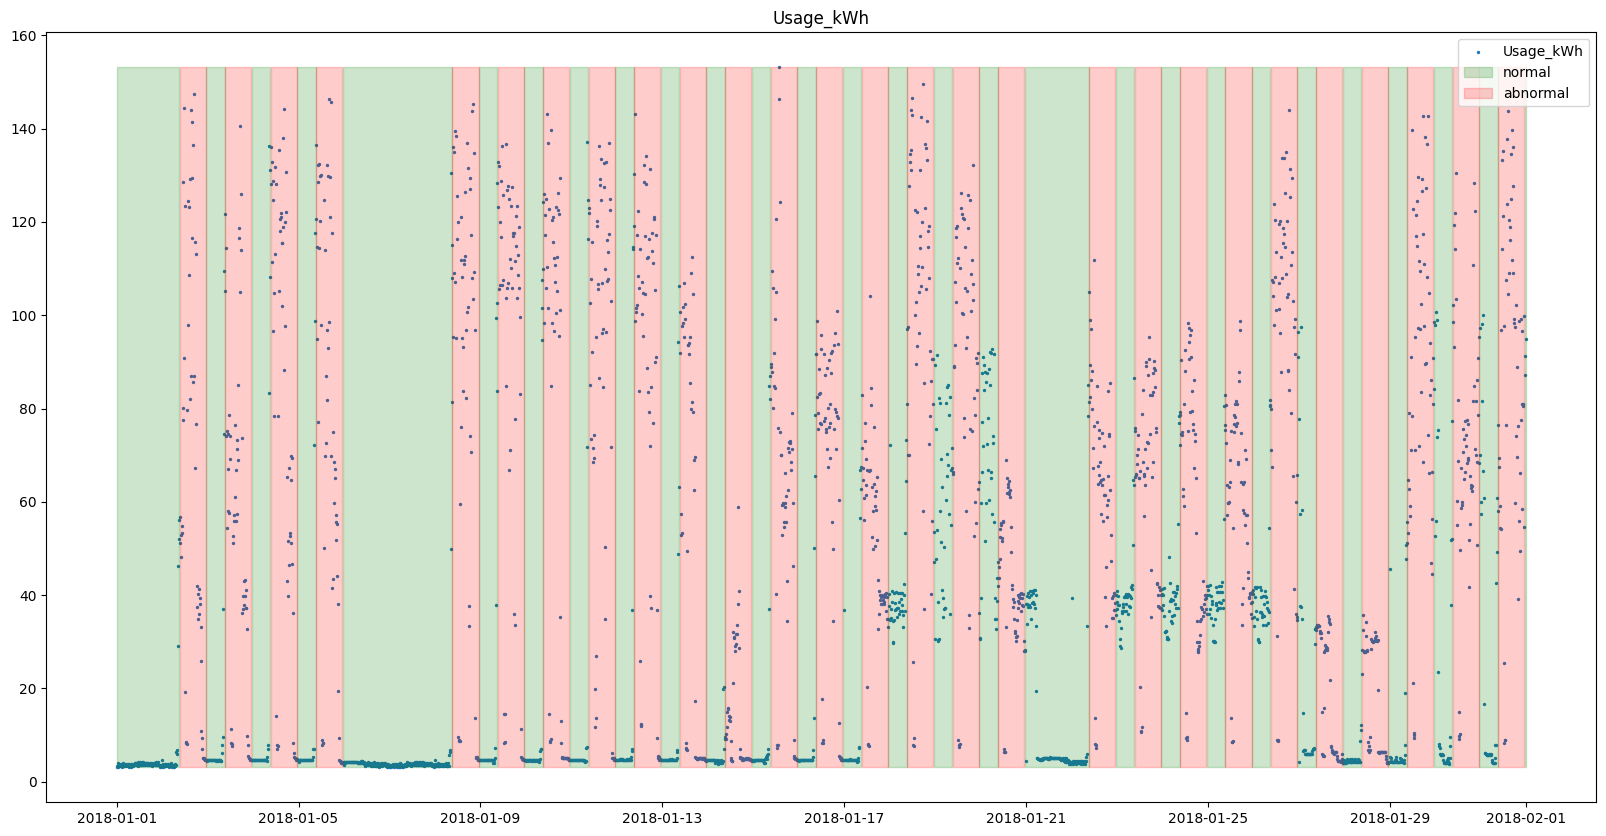

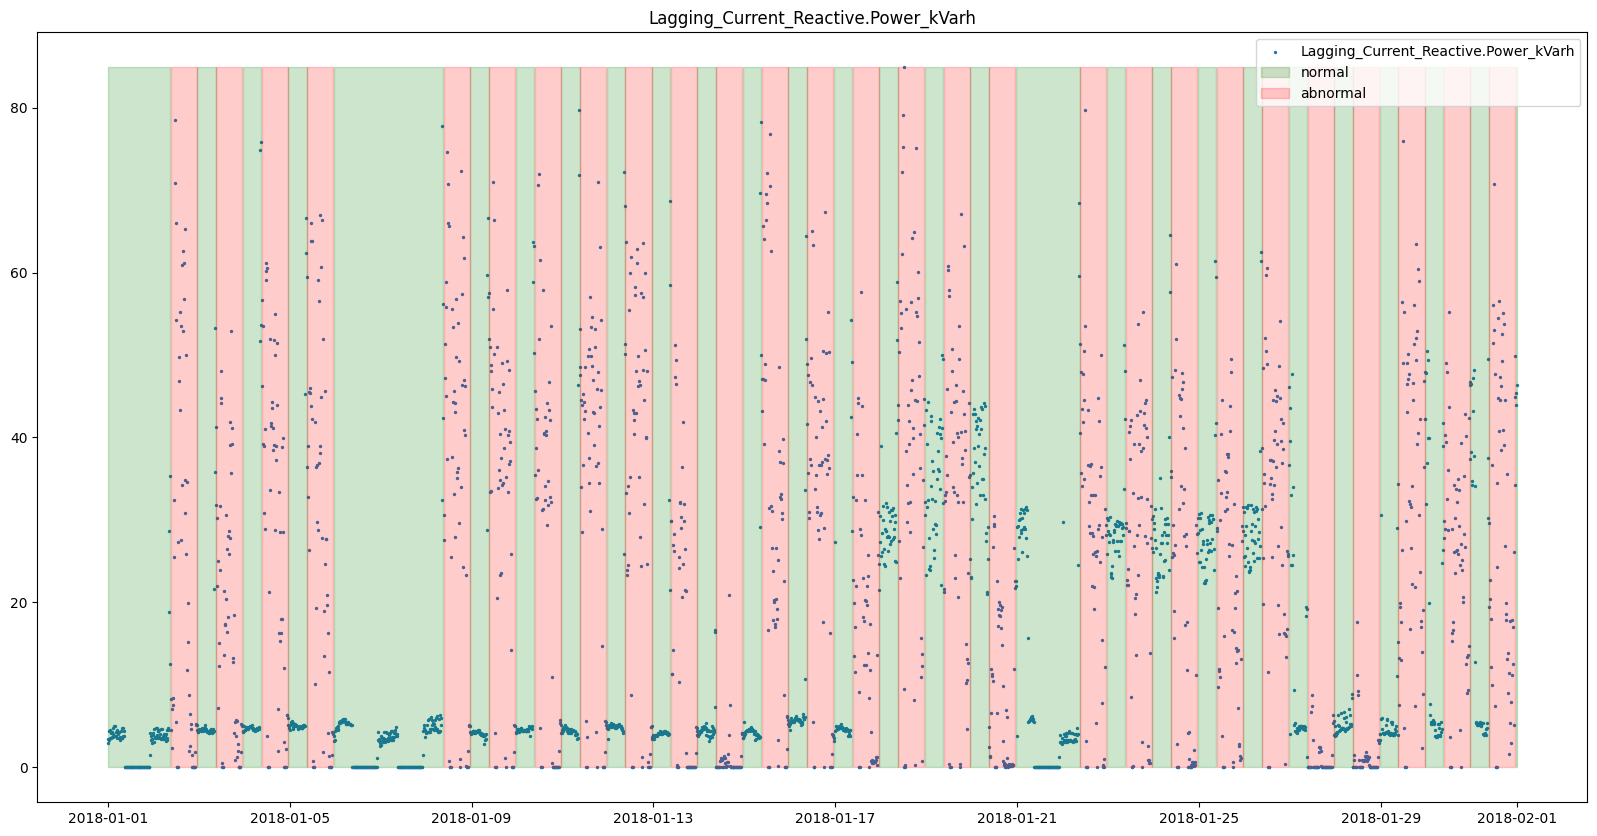

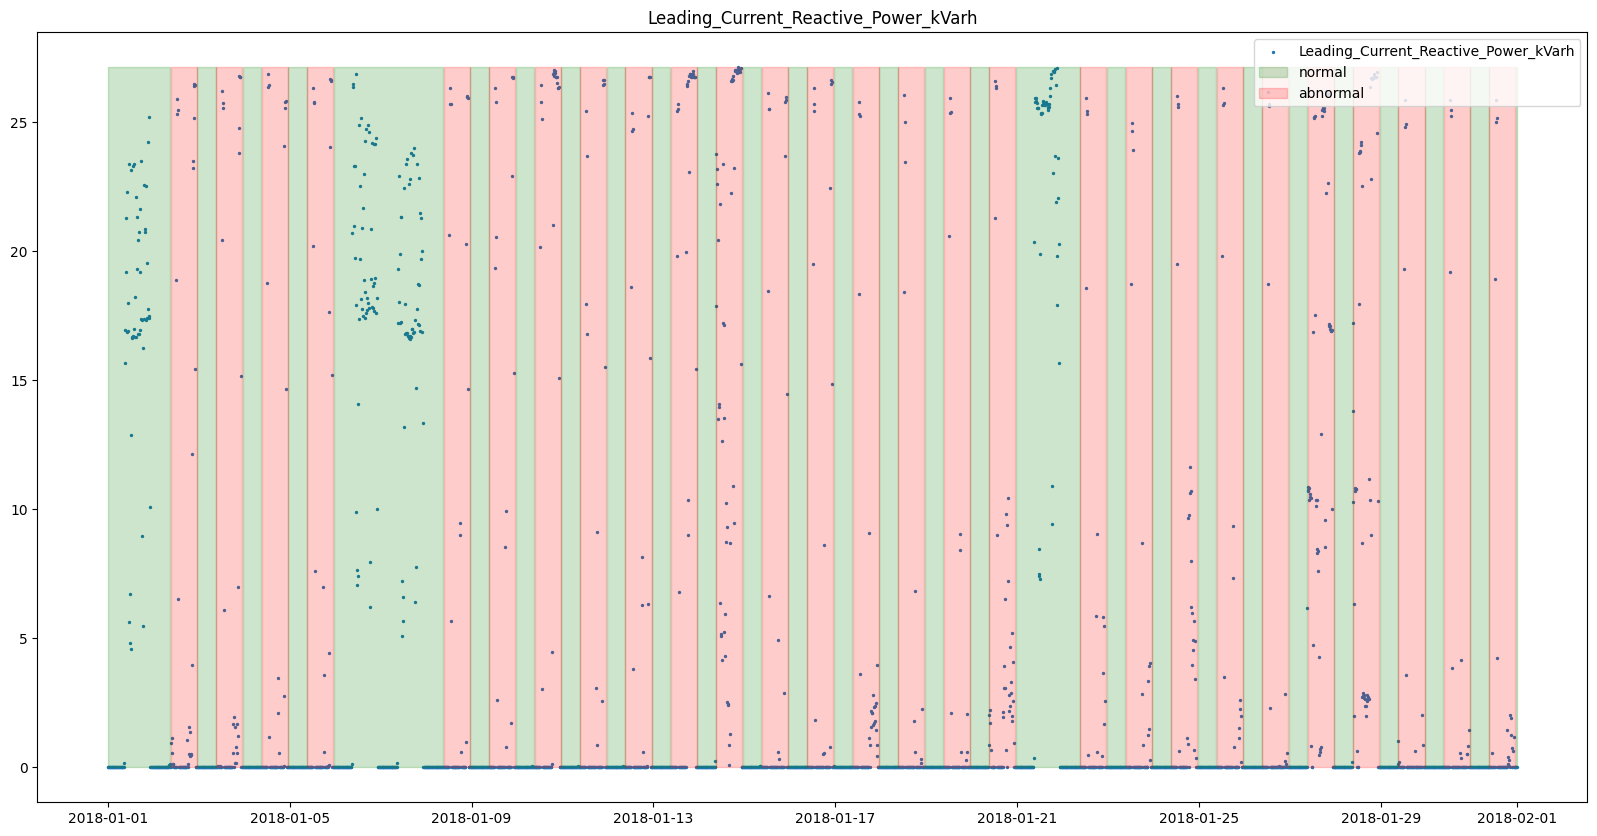

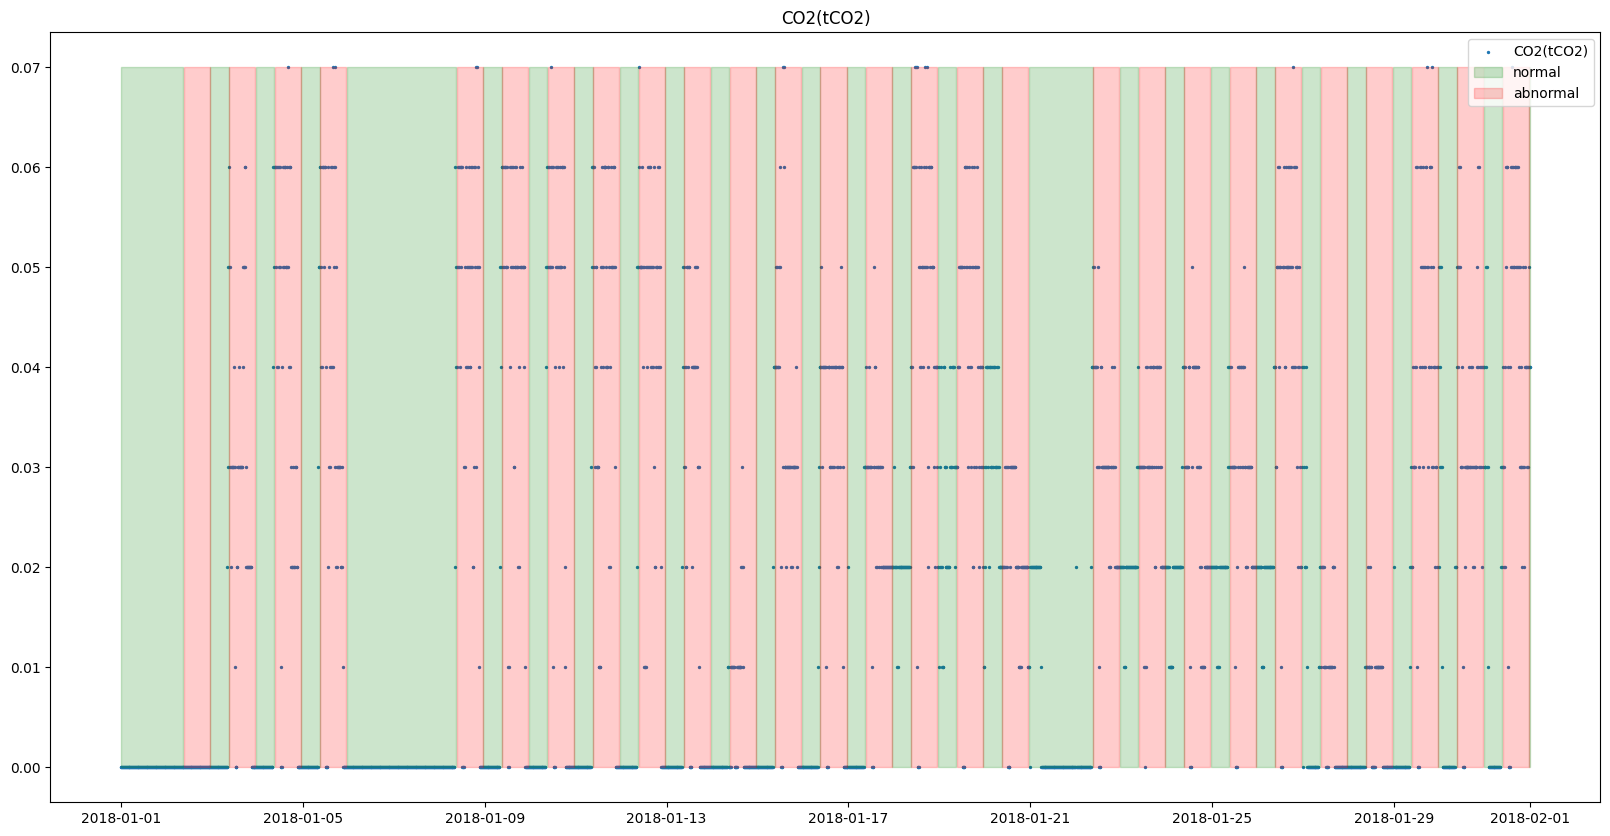

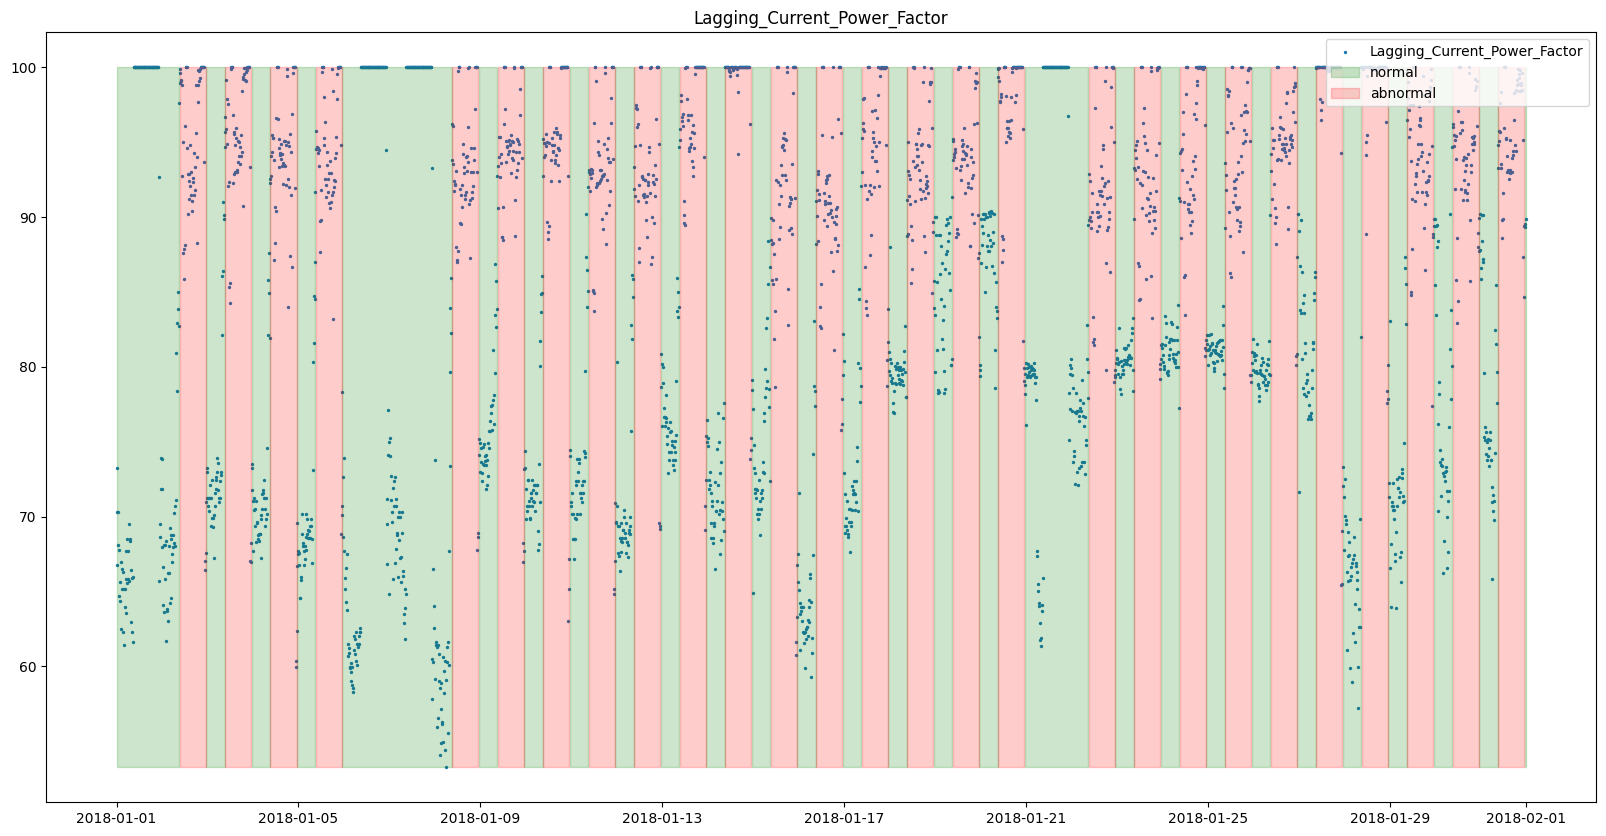

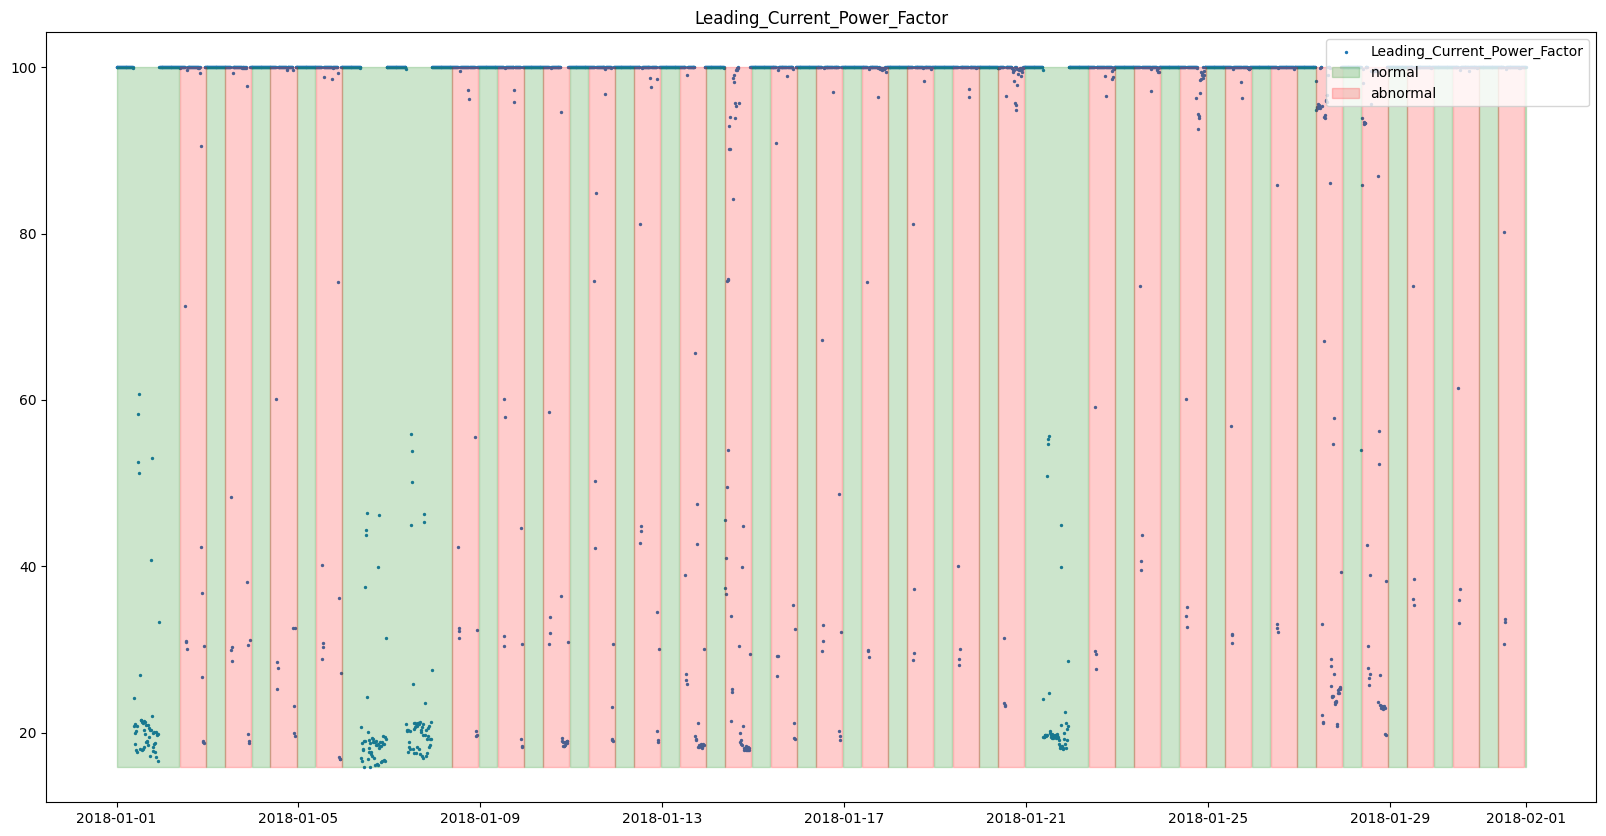

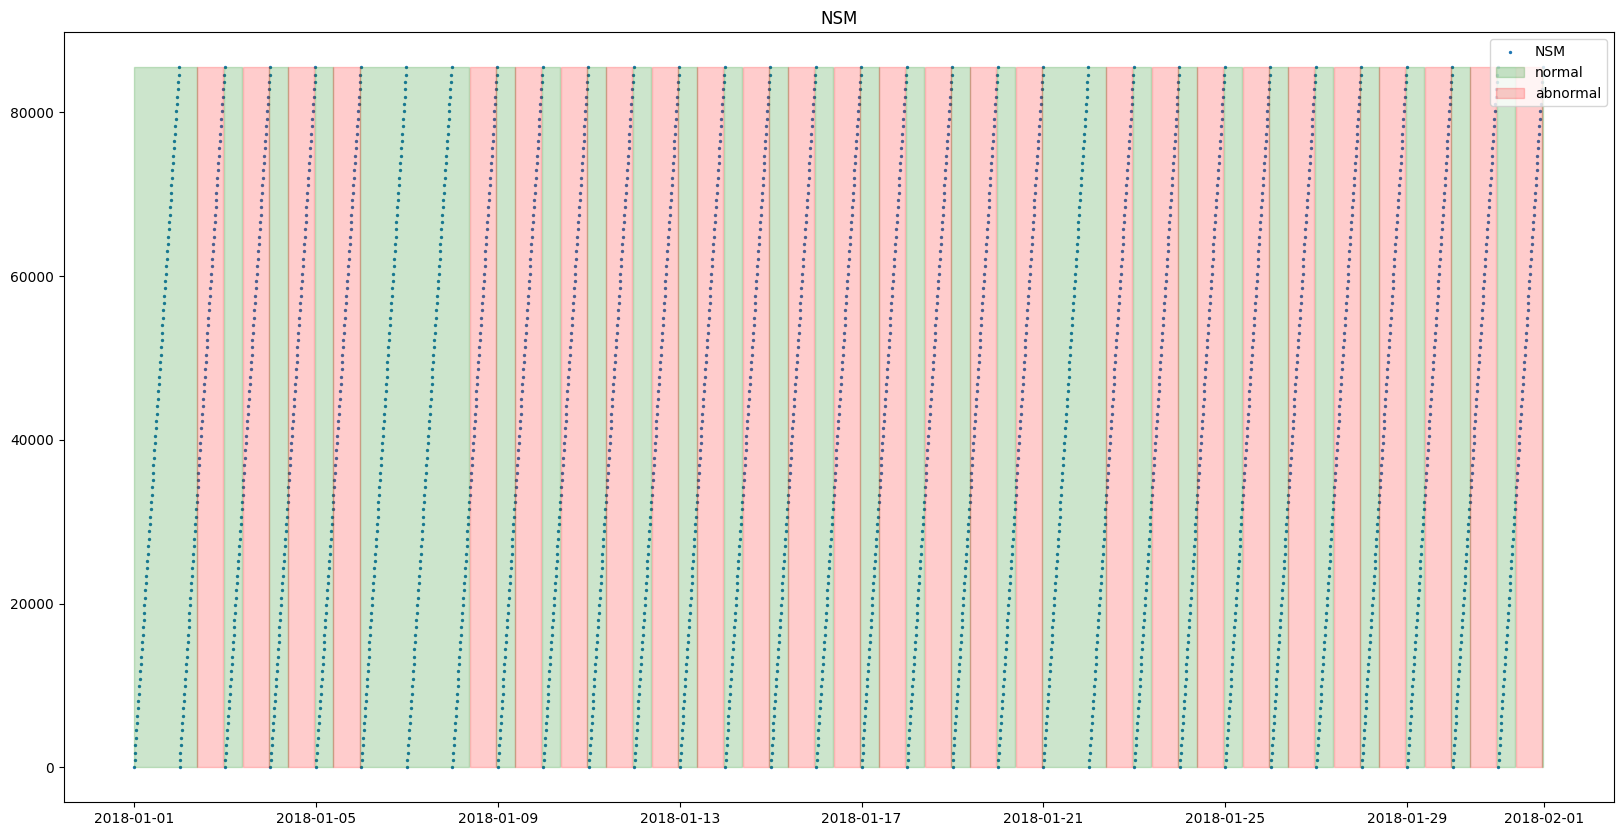

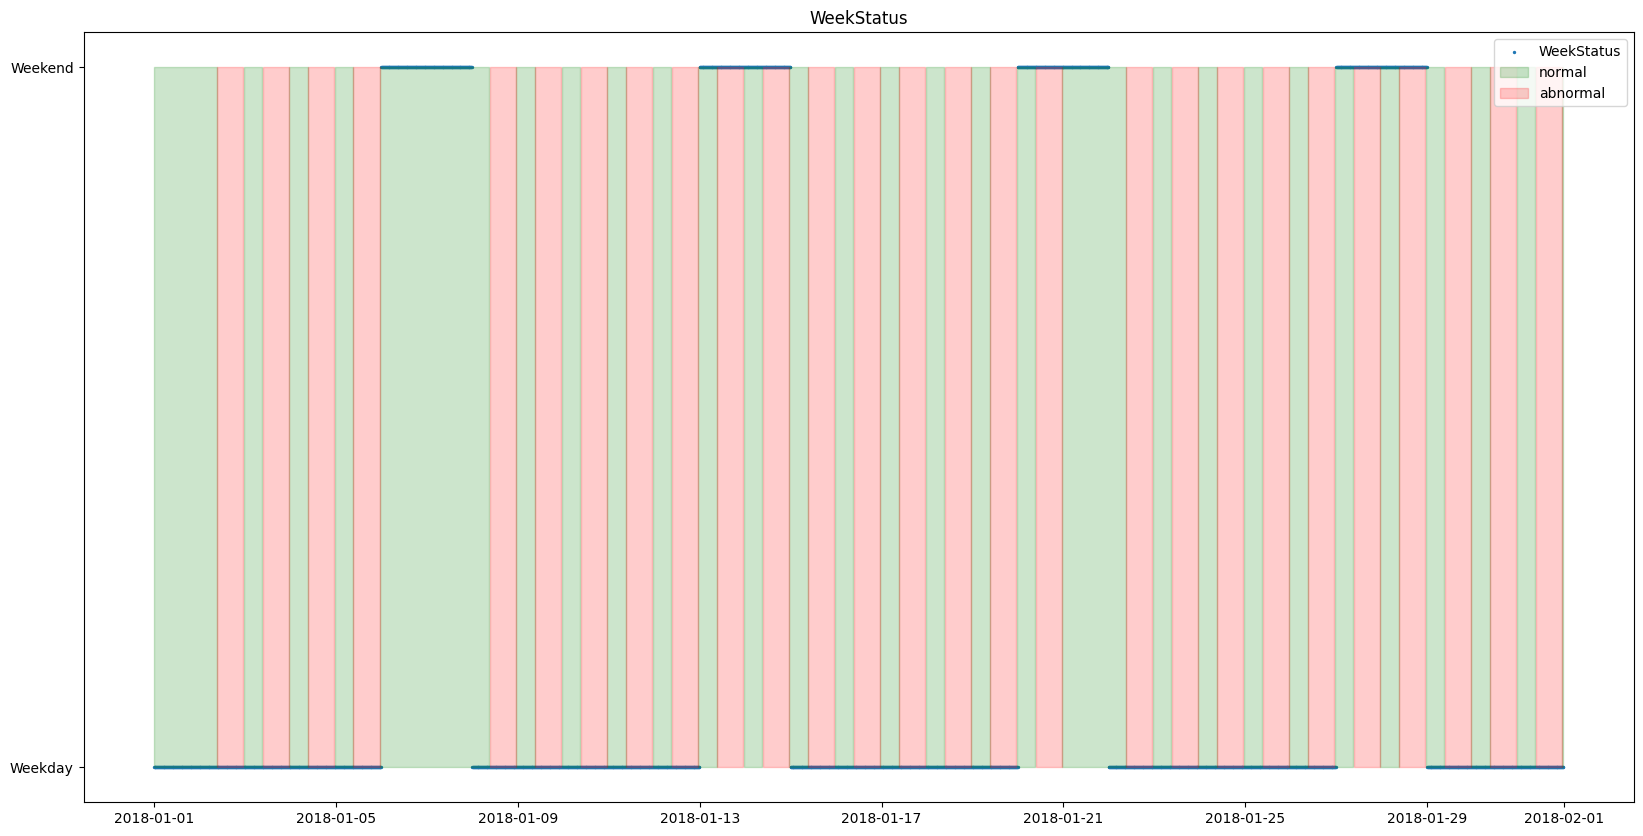

In [7]:
# 열별 이상/정상 점 그래프 확인 (예시: 1월 데이터)
for i in range(len(df.columns)-3):
  plot_normal_abnormal(df1, df.columns[i])
plt.show()

In [8]:
# 정상/이상 데이터 비율 확인
normal_df = df[df['label'] == 0]
abnormal_df = df[df['label'] == 1]
print(len(normal_df), len(abnormal_df))

18072 16968


In [9]:
#라벨링된 데이터 저장
df.to_csv('data/processed_steel_industry_data.csv', encoding='utf-8-sig')